<a href="https://colab.research.google.com/github/dlafarga//Modern-technology-for-climate-data-and-analysis/blob/main/3D_visualization_Tutorial(GODAS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D Vizualization for GODAS
## Created by Danielle Lafarga 3/6/2026

The following is an outline of this code:

- ## Section 1: Import libraries and define functions
  - this section will import all necessary libraries and define the functions that save the dimension variables and data.
- ## Section 2: Read in data
  - This section will read in the data using the function in section 1. Be sure to change the directories accordingly.
- ## Section 3: Plot cross-sections in 3D
  - ### 3.1 Depth cross-section
    - plots the data for a single depth
  - ### 3.2 Zonal Cross-section
    - plots the data for a single latitude value
  - ### 3.3 Meridional Cross-section
    - plots the data for a single longitude value
  - ### 3.4 All cross-section plotted as cube
    - plots all previous cross-sections visualized together in a 3D cube
- ## Section 4: Making a GIF
  - ### 4.1 Depth cross-section
    - Animates depth cuts globally
  - ### 4.2 Zonal Cross-section
    - Animates latitude cuts in the Pacific
  - ### 4.3 Meridional Cross-section
    - Animates longitude cuts in the Pacific


# Section 1: Import libraries and define functions
Outline for functions used to read in and preprocess data:
- get_var: Used to read in the latitude, longitude, and depth variables of the data we are plotting. **This is heavily dependent on the names of the variables in the data file.**
- read_data: this reads in the data file

Outline of functions that format the figures:
- format_longitude and format_latitude: These remove the degree symbols for the axis labels of the figure.

In [1]:
# all visualization libraries
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# to get path
import os

# libraries to read data
import netCDF4 as nc
from netCDF4 import Dataset as ds
import numpy as np

# libraries used for some math
from numpy import linspace
from numpy import meshgrid
import math

# Creating the custom colorbar
top2 = cm.get_cmap('GnBu_r')   # get green blue colormap
bottom2 = cm.get_cmap('hot_r') # get hot colormap
top_array = top2(np.linspace(0, 1, 128))        # create array with colorvalues
bottom_array = bottom2(np.linspace(0, .9, 128)) # create array with colorvalues
# edit array with color values to have better transition shades
top_array[-2:,:] = bottom_array[0,:]
top_array[-3,:] = np.array([1., 0.98823529, 1., 1.])
top_array[-4,:] = np.array([0.96862745, 0.98823529, 1., 1.])
top_array[-5,:] = np.array([0.96862745, 0.98823529, 0.94117647, 1.])

newcolors2 = np.vstack((top_array, bottom_array))         # stacking color arrays on top of each other
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')   # creating new colormap

C:\Users\Dani\AppData\Local\Temp\ipykernel_9880\3696917674.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top2 = cm.get_cmap('GnBu_r')   # get green blue colormap
C:\Users\Dani\AppData\Local\Temp\ipykernel_9880\3696917674.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bottom2 = cm.get_cmap('hot_r') # get hot colormap


In [58]:
import urllib.request
# Function reads GODAS data from 2025
# Input:
#         - year: int with the year to download or read in
#         - download: boolean if true then download data
# Output:
#         - lat: 1d array with latitude values
#         - lon: 1d array with longitude values
#         - depths: 1d array with depth values
#         - temp: 4d array (time, depth, lat, lon) with temperature values
def download_read_godas_file(year, download):
    # Define a local filename to save the downloaded data
    local_filename = f'pottmp.{year}.nc'
    if download:
        # Download the file from the URL
        url = f'https://downloads.psl.noaa.gov/Datasets/godas/pottmp.{year}.nc'
        
        # Download the file from the URL
        print(f"Downloading {url} to {local_filename}...")
        urllib.request.urlretrieve(url, local_filename)
        print("Download complete.")
    
    data = ds(local_filename, 'r')
    
    lat    = data.variables['lat'][:].data    # read in latitude
    lon    = data.variables['lon'][:].data    # read in longitude
    depths = data.variables['level'][:].data  # read in depth
    temp   = data.variables['pottmp'][0,:,:,:]      # read in temperature
    temp.set_fill_value(np.nan)               # set fill value to NaN
    temp = temp.filled()                      # fill with NaN
    data.close()
    return lat, lon, depths, temp

In [5]:
#################################################################################################################
#################################################################################################################
# Function formats longitude to get rid of degree symbols
# Input:
#         - longitude: int with longitude from 0 to 360
# Ouput:
#         - string with longitude value and W (west) or E (east)
def format_longitude(longitude):
    if not 0 <= longitude <= 360:
        return "Invalid longitude. Must be between 0 and 360 degrees."

    if longitude == 0:
        hemisphere = ''
        degrees = longitude
    elif longitude < 180:
        hemisphere = 'E'
        degrees = longitude
    elif longitude == 180:
        hemisphere = ''
        degrees = longitude
    else:
        hemisphere = 'W'
        degrees = 360 - longitude

    return f"{degrees:.0f}{hemisphere}"

#################################################################################################################
#################################################################################################################

# Function formats latitude to get rid of degree symbols
# Input:
#         - latitude: int with latitude in degrees. Positive values are N and negative are S.
# Output:
#         - string with absolute value of latitude and S or N
def format_latitude(latitude):
    if not -90 <= latitude <= 90:
        return "Invalid latitude. Must be between -90 and 90 degrees."
# adding S or N based on negative or positive value
    if latitude > 0:
        hemisphere = "N"
    elif latitude == 0:
        hemisphere = ""
    else:
        hemisphere = 'S'

    degrees = abs(latitude)

    return f"{degrees:.0f}{hemisphere}"


# Section 2: Read in data
Main variables:
- lat: 1D array with 1/3$^\circ$  latitude values (-74.5, 64.499)
- lon: 1D array with 1$^\circ$ longitude values (0.5, 359.5)
- depths: 1D array with depth values from 5 to 4,478 meters
- temp: 3D array(depth, lat, lon) with temperature values in Kelvin

In [164]:
year = 2025 # the year to read in 
download = False # should we download data or not
lat, lon, depths, temp = download_read_godas_file(year, download)

# Section 3: Plot cross-sections in 3D
There is one main function that does most of the plotting. You can find the documentation of the function at https://matplotlib.org/stable/gallery/mplot3d/box3d.html.

For each subsection, assume:
- X-axis is longitude
- Y-axis is latitude
- Z-axis is depth

The subsections are repetitive, so **the majority of the setup is explained in subsection 3.1**

All of the code in this section is used as a base to create a function to animate multiple cross-sections



## 3.1 Depth cross-section

### **Setting up region**
We define the variables **X, Y,** and **Z** as 3D arrays with their respective longitude, latitude, and depth values using meshgrid. Since our **goal is to visualize cross sections of a region**, we index specific dimension values:
```
X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])
```
For example, we visualize the North Pacific by defining the indices as:

```
lat_cut_start = 224    # index for the equator
lat_cut_end   = 404    # index for 60 N
lon_cut_start = 159    # index for 160 E
lon_cut_end   = 300    # index for 60 W
depth_cut_end = 27     # index for 459 meters
```
These values can be changed to any region. It is just a matter of knowing what region you would like and finding the indices of the latitudes and longitudes.

### **Main visualization function explaination**
The main function for the depth cross-section is called as:
```
ax.contourf(X[:,:,0], Y[:,:,0], data, zdir='z', offset=-depths[0], levels=levels, cmap=newcmp2, norm=norm,vmin=vmin, vmax=vmax)
```

<br>

**X** and **Y** are 3D arrays with longitude, latitude, and depth values (in that order) created previously from the meshgrid.


Since we are plotting on the Z axis, the depth value remains constant for every variable. In our case we are plotting the surface, so we call the first depth index $[:,:,0]$ for **X** and **Y**.

Note: The **X** and **Y** values are the same for every depth so we can use any index as long as it is indexing depth (e.g., X$[:,:,1]$).

<br>


The **data** is a 2D (lat, lon) array containing the depth cross-section. It comes from indexing the **temp** array for the specified depth and region. For the surface we can define **data** as:
```
data = temp[0, lat_cut_start:lat_cut_end,lon_cut_start:lon_cut_end]
```

The **data** is always passed as the argument for the dimension that is held constant. In this case because it is depth, **data** is passed as the thrid argument.


<br>

The argument **zdir** is the direction the cross-section will be plot in. You will want to set **offset** as a number defined in this same direction. In our example because **zdir = 'z'** which is defined as depth, we set **offset** as the first depth value.

Note: We define the surface as 0. Anything above the surface would be positive and anything below the surface is negative. Since our data has its depth layers defined as going deeper we add a negative to the depth values when plotting.

<br>

The last 4 arguments have to do with the colorbar setting the colormap, norm mapping, the lower limit, and top limit of the colorbar, respectively.

In [ ]:
#############################################################################
'''
# --- Set up cube for the North Pacific ---
'''
lat_cut_start = 224    # index for the equator
lat_cut_end   = 404    # index for 60 N
lon_cut_start = 159    # index for 160 E
lon_cut_end   = 300    # index for 60 W
depth_cut_end = 27     # index for 459 meters

# create grid for each lat, lon, and depth variable
X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])

# creating the depth cross-section at surface
surface3D = temp[0, lat_cut_start:lat_cut_end,lon_cut_start:lon_cut_end]      # surface cross-section

#############################################################################
'''
# --- Setup Figure ---
'''
fig = plt.figure(figsize=(11, 13))
title_sz = 20
label_sz = title_sz-5

ax = fig.add_subplot(111, projection='3d')  # This is what defines the plot as 3D

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end], 20)
lat_ticks   = np.arange(np.round(lat[lat_cut_start]), np.ceil(lat[lat_cut_end]), 20)
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25



# Contourf colorbar Norms
vmin, vmax = np.nanmin(surface3D), np.nanmax(surface3D) # Change to scale better
levels = 32                                             # set how many colors you want to plot
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

#############################################################################
# plot the top of the box

# offset will place the cross-section in the right position on the Z axis
cs2 = ax.contourf(X[:, :, 0], Y[:, :, 0], surface3D, zdir='z', offset=-depths[0],
                  levels=levels, cmap=newcmp2, norm=norm, vmin=vmin, vmax=vmax)
# plotting land as black
mask = np.isnan(surface3D)                                                 # create a mask for the NaN values
masked_array = np.where(mask, surface3D, np.nan)                           # change points with values to NaN
masked_array = np.where(~mask, masked_array, vmin)                         # change NaN points to values
_ = ax.contourf(X[:, :, 0], Y[:, :, 0], masked_array, zdir='z', offset=-depths[0], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land as black

#############################################################################
# The following is VERY important
# It makes sure the bounds are defined accurately
# If your bounds are not defined well your plot will not show up!!!
# Formatting labels
ax.grid(True)
ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left') # Requires format_longitude function to remove degree symbol
ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45)  # Requires format_latitude function to remove degree symbol
ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
ax.tick_params(axis='x', pad=0, labelsize=label_sz)
ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
ax.tick_params(axis='z', pad=7,  labelsize=label_sz)


# Label Axes
ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=36)
ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=24)
ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=12, rotation=0)

# TITLE PLEASE CHANGE TO MATCH DATA
ax.set_title("GODAS January 2025", fontsize=title_sz)

# Set limits
ax.set_xlim(lon_ticks[0], lon_ticks[-1])
ax.set_ylim(lat_ticks[0], lat_ticks[-1])
ax.set_zlim(-depth_ticks[-1], 0)


#############################################################################

# view from above to make sure plot matches
ax.view_init(elev=40, azim=-145, vertical_axis='z')
ax.set_box_aspect(aspect=(1, 1, 1), zoom=0.8)

#############################################################################
# the colorbar for the data
cbar = fig.colorbar(cs2, fraction=0.03, pad = 0)
cbar.ax.set_title("K", fontsize = label_sz)
cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
cbar.update_ticks()

## 3.2 Zonal Cross-section
We use the same main function with a few changes to do a zonal cross-section.

```
ax.contourf(X[0, :, :], data, Z[0,:,:], zdir='y', offset = lat[lat_cut_start], levels=levels, cmap=newcmp2, norm=norm, vmin=vmin, vmax=vmax)
```

We hold the latitude consitant which is the first index of **X** and **Z**. All values are the same throughout the first index similar to the previous section. For consistency we wanted to plot the first cut value so we use the index **0**.

**zdir** and **offset** are also changed to reflect the positioning of the cross-section at the first latitude value for the North Pacific, **lat[lat_cut_start]**, in the y-axis.

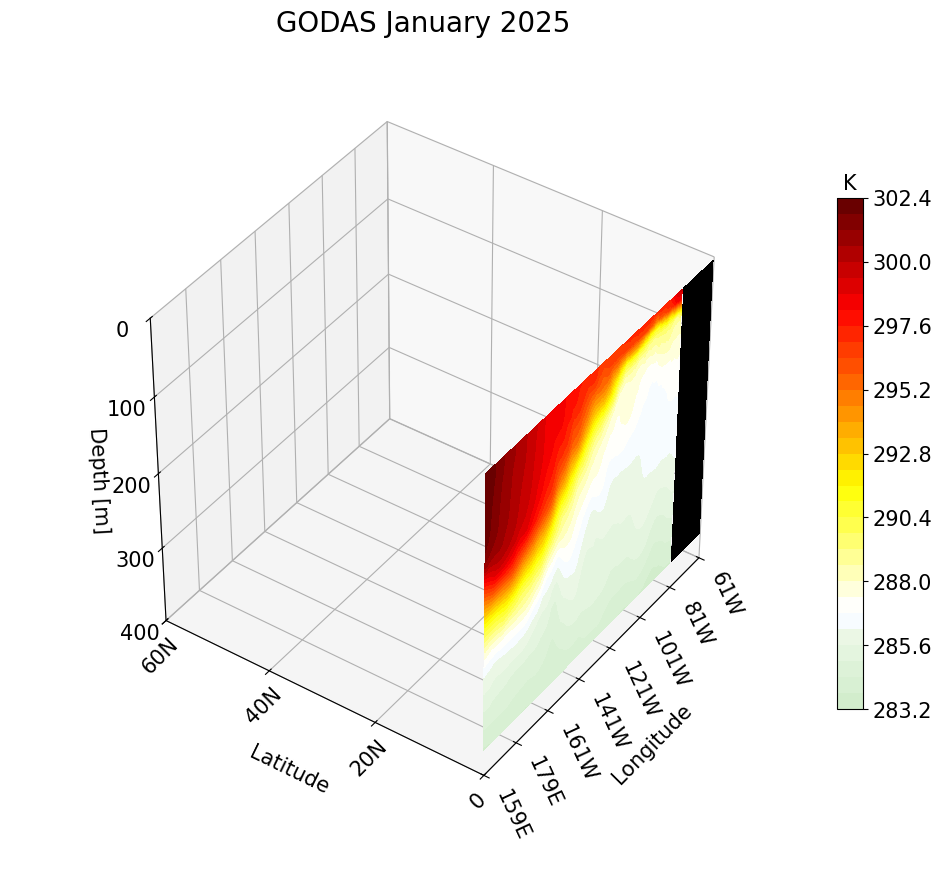

In [ ]:
#############################################################################

# Set up cube for the North Pacific
lat_cut_start = 224    # index for the equator
lat_cut_end   = 404    # index for 60 N
lon_cut_start = 159    # index for 160 E
lon_cut_end   = 300    # index for 60 W
depth_cut_end = 27     # index for 459 meters


# create grid for each lat, lon, and depth variable
X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])

# creating the zonal cross-section at equator
lat_depth3D = temp[:depth_cut_end , lat_cut_start, lon_cut_start:lon_cut_end] # zonal cross-section

#############################################################################

# --- Setup Figure ---
fig = plt.figure(figsize=(11, 13))
title_sz = 20
label_sz = title_sz-5

ax = fig.add_subplot(111, projection='3d')  # This is what defines the plot as 3D

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end], 20)
lat_ticks   = np.arange(np.round(lat[lat_cut_start]), np.ceil(lat[lat_cut_end]), 20)
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25


# Contourf colorbar Norms
vmin, vmax = np.nanmin(surface3D), np.nanmax(surface3D) # Change to scale better
levels = 32                                             # set how many colors you want to plot
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
#############################################################################
# Plot zonal cross-section
cs2 = ax.contourf(X[0, :, :], lat_depth3D.T, Z[0,:,:], zdir='y', levels=levels, cmap=newcmp2, offset= lat[lat_cut_start],
            norm=norm, vmin=vmin, vmax=vmax)

# plotting land
mask = np.isnan(lat_depth3D)                                # create a mask for the NaN values
masked_array = np.where(mask, lat_depth3D, np.nan)          # change points with values to NaN
masked_array = np.where(~mask, masked_array, vmin)          # change NaN points to values
_ = ax.contourf(X[0, :, :], masked_array.T, Z[0,:,:], zdir='y', offset=lat[lat_cut_start], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land

#############################################################################
# The following is VERY important
# It makes sure the bounds are defined accurately
# If your bounds are not defined well your plot will not show up!!!
# Formatting labels
ax.grid(True)
ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left') # Requires format_longitude function to remove degree symbol
ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45)  # Requires format_latitude function to remove degree symbol
ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
ax.tick_params(axis='x', pad=0, labelsize=label_sz)
ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
ax.tick_params(axis='z', pad=7,  labelsize=label_sz)


# Label Axes
ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=36)
ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=24)
ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=12, rotation=0)

ax.set_title("GODAS January 2025", fontsize=title_sz)


# Set limits
ax.set_xlim(lon_ticks[0], lon_ticks[-1])
ax.set_ylim(lat_ticks[0], lat_ticks[-1])
ax.set_zlim(-depth_ticks[-1], 0)


#############################################################################

# view from above to make sure plot matches
ax.view_init(elev=40, azim=-145, vertical_axis='z')
ax.set_box_aspect(aspect=(1, 1, 1), zoom=0.8)

#############################################################################
# the colorbar for the data
cbar = fig.colorbar(cs2,fraction=0.03, pad = 0)
cbar.ax.set_title("K", fontsize = label_sz)
cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
cbar.update_ticks()


## 3.3 Meridional Cross-section
We use the same main function with a few changes to do a merdional cross-section.

```
ax.contourf(data, Y[:,0,:], Z[:,0,:], zdir='x', offset = offset=lon_ticks[0], levels=levels, cmap=newcmp2, norm=norm, vmin=vmin, vmax=vmax)
```

We hold the longitude consitant which is the second index of **Y** and **Z**.

**zdir** and **offset** are also changed to reflect the positioning of the cross-section in the x-axis.

/tmp/ipykernel_2215/3947610172.py:68: UserWarning: Adding colorbar to a different Figure <Figure size 1100x1300 with 3 Axes> than <Figure size 1100x1300 with 1 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cs2,fraction=0.03, pad = 0)


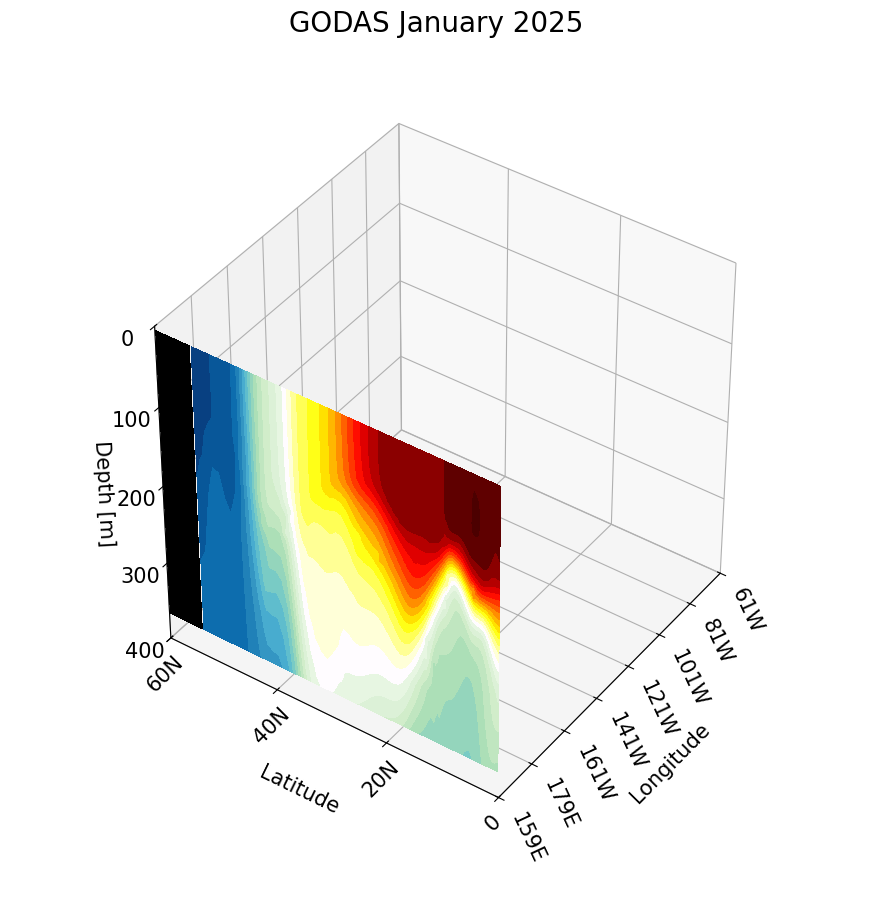

In [ ]:
#############################################################################

# Set up cube for the North Pacific
lat_cut_start = 224    # index for the equator
lat_cut_end   = 404    # index for 60 N
lon_cut_start = 159    # index for 160 E
lon_cut_end   = 300    # index for 60 W
depth_cut_end = 27     # index for 459 meters


# create grid for each lat, lon, and depth variable
X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])

# creating the cross-section surfaces
lon_depth3D = temp[:depth_cut_end , lat_cut_start:lat_cut_end, lon_cut_start] # meridional cross-section
#############################################################################

# --- Setup Figure ---
fig = plt.figure(figsize=(11, 13))
title_sz = 20
label_sz = title_sz-5

ax = fig.add_subplot(111, projection='3d')  # This is what defines the plot as 3D



# Contourf colorbar Norms
vmin, vmax = np.nanmin(lon_depth3D), np.nanmax(lon_depth3D) # Change to scale better
levels = 32                                             # set how many colors you want to plot
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end], 20)
lat_ticks   = np.arange(np.round(lat[lat_cut_start]), np.ceil(lat[lat_cut_end]), 20)
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25
#############################################################################
ax.contourf(lon_depth3D.T, Y[:, 0, :], Z[:, 0, :], zdir='x', offset=lon_ticks[0], levels=levels,
            cmap=newcmp2, norm=norm, vmin=vmin, vmax=vmax)

# plotting land
mask = np.isnan(lon_depth3D) # create a mask for the NaN values
masked_array = np.where(mask, lon_depth3D, np.nan)          # change points with values to NaN
masked_array = np.where(~mask, masked_array, vmin) # change NaN points to values
_ = ax.contourf(masked_array.T, Y[:, 0, :], Z[:, 0, :], zdir='x', offset=lon_ticks[0], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land

#############################################################################
# The following is VERY important
# It makes sure the bounds are defined accurately
# If your bounds are not defined well your plot will not show up!!!
# Formatting labels
ax.grid(True)
ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left') # Requires format_longitude function to remove degree symbol
ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45)  # Requires format_latitude function to remove degree symbol
ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
ax.tick_params(axis='x', pad=0, labelsize=label_sz)
ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
ax.tick_params(axis='z', pad=7,  labelsize=label_sz)


# Label Axes
ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=36)
ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=24)
ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=12, rotation=0)

ax.set_title("GODAS January 2025", fontsize=title_sz)

# Set limits
ax.set_xlim(lon_ticks[0], lon_ticks[-1])
ax.set_ylim(lat_ticks[0], lat_ticks[-1])
ax.set_zlim(-depth_ticks[-1], 0)


#############################################################################

# view from above to make sure plot matches
ax.view_init(elev=40, azim=-145, vertical_axis='z')
ax.set_box_aspect(aspect=(1, 1, 1), zoom=0.8)

#############################################################################
# the colorbar for the data
cbar = fig.colorbar(cs2,fraction=0.03, pad = 0)
cbar.ax.set_title("K", fontsize = label_sz)
cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
cbar.update_ticks()

## 3.4 All cross-section plotted as cube

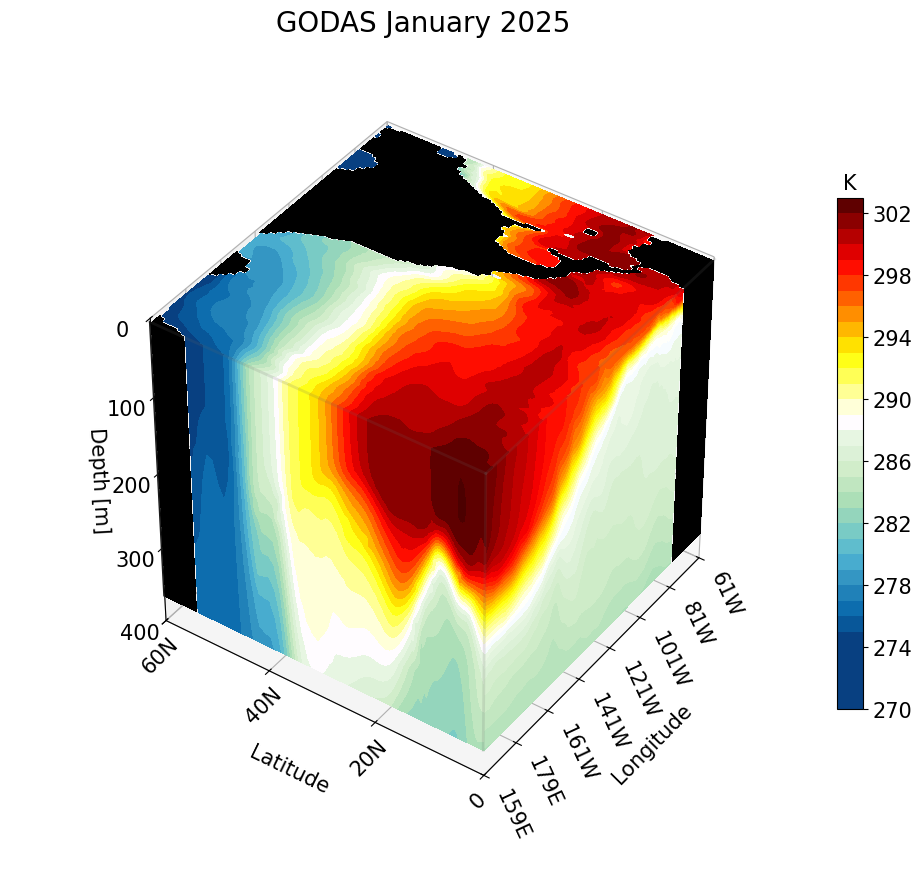

In [ ]:
# Usual set up
lat_cut_start = 224    # index for the equator
lat_cut_end   = 404    # index for 60 N
lon_cut_start = 159    # index for 160 E
lon_cut_end   = 300    # index for 60 W
depth_cut_end = 27     # index for 459 meters

# Each cross section
surface3D = temp[0, lat_cut_start:lat_cut_end, lon_cut_start:lon_cut_end]
lat_depth3D = temp[:depth_cut_end , lat_cut_start, lon_cut_start:lon_cut_end]
lon_depth3D = temp[:depth_cut_end , lat_cut_start:lat_cut_end, lon_cut_start]

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end], 20)
lat_ticks   = np.arange(np.round(lat[lat_cut_start]), np.ceil(lat[lat_cut_end]), 20)
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25

# create grid to plot in x and z for the y cross section
X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])

#############################################################################depth_ticksticksut the regions to be only the California Coast


# --- Setup Figure ---
fig = plt.figure(figsize=(11, 13))
title_sz = 20
label_sz = title_sz-5

ax = fig.add_subplot(111, projection='3d')

# Contourf colorbar Norms
vmin, vmax = np.nanmin(lon_depth3D), np.nanmax(lon_depth3D) # Change to scale better
levels = 32                                             # set how many colors you want to plot
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
#############################################################################
# plotting depth cross-section
# plotting the contours at the surface
cs2 = ax.contourf(X[:, :, 0], Y[:, :, 0], surface3D, zdir='z', offset=-depths[0],
                  levels=levels, cmap=newcmp2, norm=norm,vmin=vmin, vmax=vmax)
# plotting land
mask = np.isnan(surface3D) # create a mask for the NaN values
masked_array = np.where(mask, surface3D, np.nan)          # change points with values to NaN
masked_array = np.where(~mask, masked_array, vmin)  # change NaN points to values
_ = ax.contourf(X[:, :, 0], Y[:, :, 0], masked_array, zdir='z', offset=-depths[0], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land

#############################################################################
# plotting zonal cross-section
# plotting the contours at the equator
ax.contourf(X[0, :, :], lat_depth3D.T, Z[0,:,:], zdir='y', levels=levels, cmap=newcmp2, offset= 0,
            norm=norm, vmin=vmin, vmax=vmax)
# plotting land
mask = np.isnan(lat_depth3D) # create a mask for the NaN values
masked_array = np.where(mask, lat_depth3D, np.nan)      # change points with values to NaN
masked_array = np.where(~mask, masked_array, vmin)      # change NaN points to values
_ = ax.contourf(X[0, :, :], masked_array.T, Z[0,:,:], zdir='y', offset=0, cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land

#############################################################################
# plotting meridional cross-section
# plotting contours at 160E
ax.contourf(lon_depth3D.T, Y[:, 0, :], Z[:, 0, :], zdir='x', offset=lon_ticks[0], levels=levels,
            cmap=newcmp2, norm=norm, vmin=vmin, vmax=vmax)

# plotting land
mask = np.isnan(lon_depth3D) # create a mask for the NaN values
masked_array = np.where(mask, lon_depth3D, np.nan)          # change points with values to NaN
masked_array = np.where(~mask, masked_array, vmin) # change NaN points to values
_ = ax.contourf(masked_array.T, Y[:, 0, :], Z[:, 0, :], zdir='x', offset=lon_ticks[0], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land
#############################################################################
# formatting axis
ax.grid(True)
ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left') # Requires format_longitude function to remove degree symbol
ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45)  # Requires format_latitude function to remove degree symbol
ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
ax.tick_params(axis='x', pad=0, labelsize=label_sz)
ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
ax.tick_params(axis='z', pad=7,  labelsize=label_sz)


ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=36)
ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=24)
ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=12, rotation=0)

ax.set_title("GODAS January 2025", fontsize=title_sz)

ax.set_xlim(lon_ticks[0], lon_ticks[-1])
ax.set_ylim(lat_ticks[0], lat_ticks[-1])
ax.set_zlim(-depth_ticks[-1], 0)

# appearance and formatting
#############################
# draw edges of 3d box
#############################
edges_kw = dict(color='0.4', linewidth=2, zorder=100, alpha = .16)



# Soft line edges for the cube
ax.plot(
    [lon[lon_cut_start], lon[lon_cut_end]],
    [lat[lat_cut_start], lat[lat_cut_start]],
    [-depths[0], -depths[0]],
    **edges_kw
)

ax.plot(
    [lon[lon_cut_start], lon[lon_cut_start]],
    [lat[lat_cut_start], lat[lat_cut_end]],
    [-depths[0], -depths[0]],
    **edges_kw
)

ax.plot(
    [lon[lon_cut_start], lon[lon_cut_start]],
    [lat[lat_cut_start], lat[lat_cut_start]],
    [-depths[0], -depths[depth_cut_end-1]],
    **edges_kw
)
# depth axis line so it is obvious
ax.plot(
    [lon[lon_cut_start], lon[lon_cut_start]],
    [lat[lat_cut_end], lat[lat_cut_end]],
    [-depths[0], -depths[depth_cut_end-1]],
    **dict(color='0.1', linewidth=1, zorder=100)
)


#############################################################################

# view from above to make sure plot matches
ax.view_init(elev=40, azim=-145, vertical_axis='z')
ax.set_box_aspect(aspect=(1, 1, 1), zoom=0.8)

#############################################################################
# the colorbar for the data
cbar = fig.colorbar(cs2,fraction=0.03, pad = 0)
cbar.ax.set_title("K", fontsize = label_sz)
cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
cbar.update_ticks()

# Section 4: Making a GIF
To make a GIF, we turn each one of the cross-section visualizations into a function. The function will produce a figure which we save as a .png file. We do this for multiple cross-sections and put them together into one GIF

There are a few things that we keep separate from the function so that it is easier to customize the GIF without having to change the function:
- The setup for the region
- Defining the ticks for each axis
  - This makes sure your labels aren't too close or too far apart
- Defining the indices of the variable you want to plot
- Setting up the bounds and total color bins for the colorbar
- Creating the title

Each section will start by setting up the region, then define the plotting function, and then call the function recursively.

Each function can be broken down into 6 parts:
- figure object creation and set up
- land plotti for the base mapng
- cross-section plott
    - This also contains land plotting for the cross-sectioning
- axis labeling and formatting
- 3D view setting
- colorbar labeling and formatting


## 4.1 Depth cross-section


In [458]:
#############################################################################
#############################################################################
# Function will plot one depth cross-section for a region
# Input
#         - title: string with tite for each figure
#         - data: 3D array with data to be visualized
#         - vmin, vmax: float clip value that defines maximum and minimum for the colorbar
#         - depth_ind: int with the depth index that defines the cross-section
#         - levels: int that sets how many colors you want to plot
# Output
#         - fig: matplotlib figure object with the 3D figure
# Important variables
#         - lon_cut_start: int with starting longitude index
#         - lon_cut_end: int with end longitude index
#         - depth_cut_end: int with end depth index
# Note: make sure all tick values are defined before calling this function. This is
#       important for accurate labeling
#############################################################################
#############################################################################
def plot_depth_3D(title, data, vmin, vmax, levels, depth_ind):
    #############################################################################
    
    # --- Setup Figure ---
    fig = plt.figure(figsize=(11, 13))
    title_sz = 20
    label_sz = title_sz-5
    
    ax = fig.add_subplot(111, projection='3d')  # This is what defines the plot as 3D
    
    # Contour Norms
    fixed_levels = np.linspace(vmin, vmax, levels)  # the colorbar ticks
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    
    # create grid for each lat, lon, and depth variable
    X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])
    #############################################################################
    # creating the depth cross-section 
    depth3D = data[depth_ind, lat_cut_start:lat_cut_end,lon_cut_start:lon_cut_end]      # depth cross-section at index

    # plot the depth cross-section
    cs2 = ax.contourf(X[:, :, 0], Y[:, :, 0], depth3D, levels=fixed_levels, zdir='z', offset=-depths[depth_ind],
                       cmap=newcmp2, norm=norm, extend = 'both')
    #############################################################################
    # plotting land of cross-section as black
    mask = np.isnan(depth3D)                                                 # create a mask for the NaN values
    masked_array = np.where(mask, depth3D, np.nan)                           # change points with values to NaN
    masked_array = np.where(~mask, masked_array, vmin)                   # change NaN points to values
    _ = ax.contourf(X[:, :, 0], Y[:, :, 0], masked_array, zdir='z', offset=-depths[depth_ind], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land as black

    #############################################################################
    # The following is VERY important
    # It makes sure the bounds are defined accurately
    # If your bounds are not defined well your plot will not show up!!!
    # Formatting labels
    ax.grid(True)
    ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left') # Requires format_longitude function to remove degree symbol
    ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45)  # Requires format_latitude function to remove degree symbol
    ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
    ax.tick_params(axis='x', pad=0, labelsize=label_sz)
    ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
    ax.tick_params(axis='z', pad=7,  labelsize=label_sz)
    
    
    # Label Axes
    ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=28)
    ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=16)
    ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=12, rotation=0)
    ax.set_title(title, fontsize=title_sz)
    
    # Set limits
    ax.set_xlim(lon_ticks[0], lon_ticks[-1])
    ax.set_ylim(lat_ticks[0], lat_ticks[-1])
    ax.set_zlim(-depth_ticks[-1], 0)
    
    
    #############################################################################
    
    ax.set_box_aspect((1, 1, 1))
    # view from above to make sure plot matches
    ax.view_init(elev=40, azim=-145, vertical_axis='z')
    
    #############################################################################
    #############################################################################
    # the colorbar for the data
    cbar = fig.colorbar(cs2, fraction=0.03, pad = 0, extendfrac=0)
    cbar.ax.set_title("K", fontsize = label_sz)
    cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
    cbar.update_ticks()
    #############################################################################

    return fig

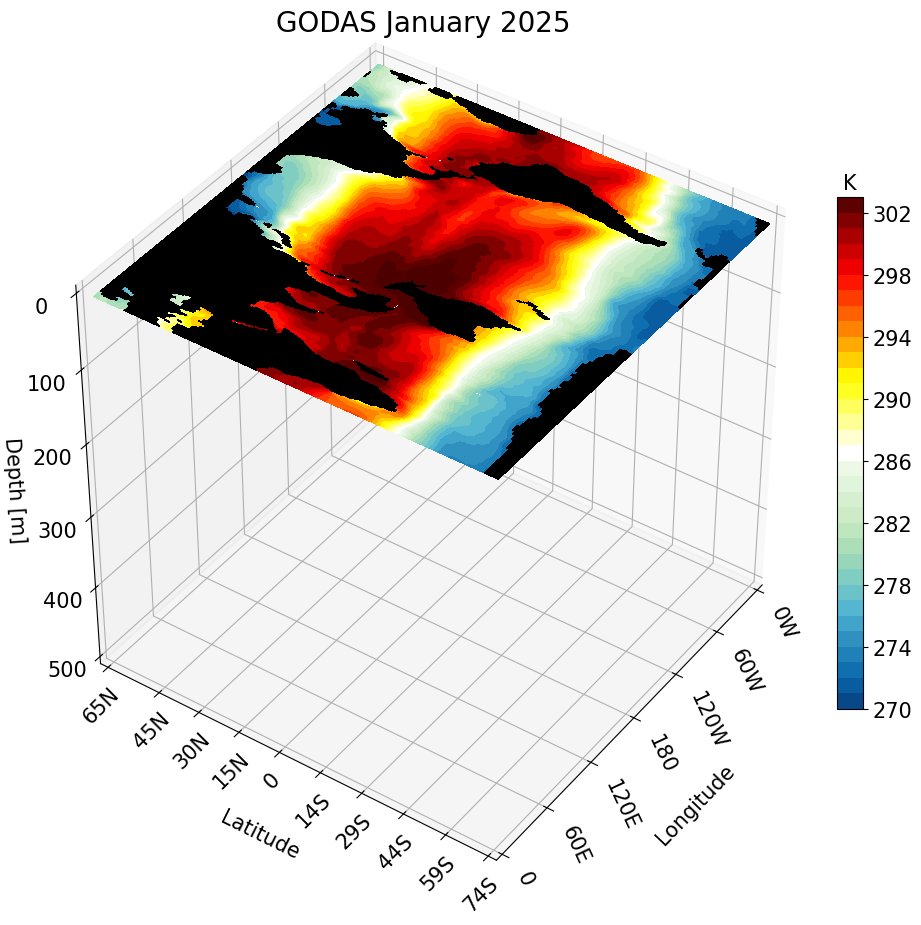

In [477]:
#############################################################################
# -- Set up for function call -- #
# Set up global region
lat_cut_start = 0    
lat_cut_end = -1     
lon_cut_start = 0   
lon_cut_end = -1    
depth_cut_end = 28

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end]+2, 60) # adding 2 to get last tick
lat_ticks   = np.arange(lat[lat_cut_start], lat[lat_cut_end], 15)
lat_ticks[-1]   = np.ceil(lat[-1])   # add the last latitude point
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25

#############################################################################
# Set up for colorbar
vmin, vmax = 270, 303 # max and min of colorbar
levels     = 34       # set how many colors you want to plot

# title for plot
title = f'GODAS January {year}'

# define indices
depth_ind = 0 # depths to plot in animation

# single function call
fig    = plot_depth_3D(title, temp, vmin, vmax, levels, depth_ind)
plt.show(fig)
plt.close(fig)

In [460]:
#############################################################################
# -- Set up for function call -- #
# Set up global region
lat_cut_start = 0    
lat_cut_end = -1     
lon_cut_start = 0   
lon_cut_end = -1    
depth_cut_end = 28

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end]+2, 60) # adding 2 to get last tick
lat_ticks   = np.arange(lat[lat_cut_start], lat[lat_cut_end], 15)
lat_ticks[-1]   = np.ceil(lat[-1])   # add the last latitude point
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25
#############################################################################

# define indices
depths_to_plot = np.arange(depth_cut_end) # depths to plot in animation

# Set up for colorbar
vmin, vmax = 270, 303 # max and min of colorbar
levels     = 34       # set how many colors you want to plot

# title for plot
title = f'GODAS January {year}'

# -- Create PNG -- #
######################################
pic_directory = os.getcwd()
# Call function and save png
for i, depth_ind in enumerate(depths_to_plot):
    fig    = plot_depth_3D(title, temp, vmin, vmax, levels, depth_ind)
    fn     = 'Depth_Cross_Section' + str(i) + '.png'
    fn     = os.path.join(pic_directory, fn)
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.close(fig)

# -- Create GiF -- #
######################################
gif_path = os.getcwd() # set GIF path
frame_files = []

# call all cross-section figures saved and put them all together
for i in range(len(depths_to_plot)):
  fn     = 'Depth_Cross_Section' + str(i) + '.png'
  fn     = os.path.join(pic_directory, fn)
  frame_files.append(fn)

output_path = os.path.join(gif_path, f'{title}_depth_animation.gif') # give gif a name based on title

frames = [Image.open(frame).convert('RGB') for frame in frame_files] # put all figs together
# save figs into one GIF
frames[0].save(
    output_path,
    save_all=True,
    append_images=frames[1:],
    duration=300,
    loop=0,
    optimize=False,  # Don't compress
    quality=500  # Maximum quality
)

# Delete the PNG files
for file in frame_files:
    os.remove(file)

print(f"{output_path} created!")

C:\Users\Dani\Desktop\3D-Visualizations\GODAS January 2025_depth_animation.gif created!


## 4.2 Zonal cross-section

In [60]:
#############################################################################
#############################################################################
# Function will plot one zonal cross-section for a region
# Input
#         - title: string with tite for each figure
#         - data: 3D array with data to be visualized
#         - vmin, vmax: float clip value that defines maximum and minimum for the colorbar
#         - lat_ind: int with the latitude index that defines the cross-section
#         - levels: int that sets how many colors you want to plot
# Output
#         - fig: matplotlib figure object with the 3D figure
# Important variables
#         - lon_cut_start: int with starting longitude index
#         - lon_cut_end: int with end longitude index
#         - depth_cut_end: int with end depth index
# Note: make sure all tick values are defined before calling this function. This is
#       important for accurate labeling
#############################################################################
#############################################################################

def plot_zonal_3D(title, data, vmin, vmax, lat_ind, levels):

    # --- Setup Figure ---
    fig = plt.figure(figsize=(12, 13))
    fig.subplots_adjust(right = .95)  # Add this line
    
    title_sz = 20
    label_sz = title_sz-3
    
    ax = fig.add_subplot(111, projection='3d')       # This is what defines the plot as 3D
    
    # Contour Norms
    fixed_levels = np.linspace(vmin, vmax, levels)   # the colorbar ticks
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    
    # create grid for each lat, lon, and depth variable
    X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])
    
    #############################################################################
    # plotting land for surface 
    surface3D = data[0, lat_cut_start:lat_cut_end,lon_cut_start:lon_cut_end]
    
    mask = np.isnan(surface3D) # create a mask for the NaN values
    masked_array = np.where(mask, surface3D, np.nan)          # change points with values to NaN
    masked_array = np.where(~mask, masked_array, vmin)        # change NaN points to values
    _ = ax.contourf(X[:, :, 0], Y[:, :, 0], masked_array, zdir='z', offset=-depths[0], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land
    # Contours
    #############################################################################
    # plotting the cross-section
    lat_depth3D = data[:depth_cut_end , lat_ind, lon_cut_start:lon_cut_end] # define the cross-section from the cut and index
    
    # plot the cross-section contour
    cs2 = ax.contourf(X[0, :, :], lat_depth3D.T, Z[0,:,:], zdir='y', levels=fixed_levels, cmap=newcmp2, offset= lat[lat_ind],
               norm = norm, extend = 'both')
    #############################################################################
    # plotting land for cross-section
    mask = np.isnan(lat_depth3D)                                # create a mask for the NaN values
    masked_array = np.where(mask, lat_depth3D, np.nan)          # change points with values to NaN
    masked_array = np.where(~mask, masked_array, vmin)          # change NaN points to values
    _ = ax.contourf(X[0, :, :], masked_array.T, Z[0,:,:], zdir='y', offset=lat[lat_ind], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land

    #############################################################################
    ax.grid(True)
    ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left')  # Requires format_longitude function to remove degree symbol
    ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45, va = 'center')  # Requires format_latitude function to remove degree symbol
    ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
    ax.tick_params(axis='x', pad=0, labelsize=label_sz)
    ax.tick_params(axis='y', pad=6,  labelsize=label_sz)
    ax.tick_params(axis='z', pad=7,  labelsize=label_sz)
    
    ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=47)
    ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=16)
    ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=14, rotation=0)
    ax.set_title(title, fontsize=title_sz)
    
    # Set limits
    ax.set_xlim(lon_ticks[0], lon_ticks[-1])
    ax.set_ylim(lat_ticks[0], lat_ticks[-1])
    ax.set_zlim(-depth_ticks[-1], 0)
    
    #############################################################################
    ax.set_box_aspect((1, 1, 1))
    
    # view from above to make sure plot matches
    ax.view_init(elev=40, azim=-150, vertical_axis='z')
    #############################################################################
    #############################################################################
    # the colorbar for the data
    cbar = fig.colorbar(cs2, fraction=0.03, pad = 0, extendfrac=0)
    cbar.ax.set_title("K", fontsize = label_sz)
    cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
    cbar.update_ticks()
    #############################################################################
    
    return fig

In [166]:
# -- Set up for function call --
######################################
# Set up for the North Pacific
lat_cut_start = 134    # index for 30 S
lat_cut_end   = 405    # index for 60 N
lon_cut_start = 160    # index for 160 E
lon_cut_end   = 301    # index for 60 W
depth_cut_end = 27     # index for 459 meters

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end], 20)
lat_ticks   = np.round(np.arange(lat[lat_cut_start], lat[lat_cut_end], 10)) # round these because the scale is 1/3 and we want to round up
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25

# Defining the latitudes to visualize
lat_indices = np.arange(lat_cut_start, lat_cut_end, 3)

# Set up for colorbar
vmin, vmax = 270, 303 # Change to scale better
colors     = 32       # set how many colors you want to plot

# title for plot
title = f'GODAS January {year}'

# -- Create PNG -- #
######################################
pic_directory = os.getcwd()
# create cross-section figures and save as PNG
for i, lat_ind in enumerate(lat_indices):
    fig = plot_zonal_3D(title, temp, vmin, vmax, lat_ind, colors)
    fn     = 'Zonal_Cross_Section' + str(i) + '.png'
    fn     = os.path.join(pic_directory, fn)
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.close(fig)

# -- Create GiF --
######################################
import imageio
from PIL import Image
import glob

gif_path = os.getcwd() # set GIF path
frame_files = []
# call all cross-section figures saved
for i in range(len(lat_indices)):
  fn     = 'Zonal_Cross_Section' + str(i) + '.png'
  fn     = os.path.join(pic_directory, fn)
  frame_files.append(fn)

output_path = os.path.join(gif_path, f'{title}_animation.gif') # give gif a name based on title

frames = [Image.open(frame).convert('RGB') for frame in frame_files] # put all figs together
# save figs
frames[0].save(
    output_path,
    save_all=True,
    append_images=frames[1:],
    duration=200,
    loop=0,
    optimize=False,  # Don't compress
    quality=500  # Maximum quality
)

# Delete the PNG files
for file in frame_files:
    os.remove(file)

print(f"{output_path} created!")

C:\Users\Dani\Desktop\3D-Visualizations\GODAS January 2025_animation.gif created!


## 4.3 Meridional cross-section

In [399]:
#############################################################################
#############################################################################
# Function will plot one depth cross-section for a region
# Input
#         - title: string with tite for each figure
#         - data: 3D array with data to be visualized
#         - vmin, vmax: float clip value that defines maximum and minimum for the colorbar
#         - lon_ind: int with the longitude index that defines the cross-section
#         - levels: int that sets how many colors you want to plot
# Output
#         - fig: matplotlib figure object with the 3D figure
# Important variables
#         - lon_cut_start: int with starting longitude index
#         - lon_cut_end: int with end longitude index
#         - depth_cut_end: int with end depth index
# Note: make sure all axis tick values are defined before calling this function. This is
#       important for accurate labeling
#############################################################################
#############################################################################
def plot_meridional_3D(title, data, vmin, vmax, levels, lon_ind):
    #############################################################################
    
    # --- Setup Figure ---
    fig = plt.figure(figsize=(11, 13))
    title_sz = 20
    label_sz = title_sz-5
    
    ax = fig.add_subplot(111, projection='3d')  # This is what defines the plot as 3D
    
    # Contour Norms
    fixed_levels = np.linspace(vmin, vmax, levels)  # the colorbar ticks
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # create grid for each lat, lon, and depth variable
    X, Y, Z = np.meshgrid(lon[lon_cut_start:lon_cut_end], lat[lat_cut_start:lat_cut_end], -depths[0:depth_cut_end])

    lon_depth3D = data[:depth_cut_end , lat_cut_start:lat_cut_end, lon_ind] # meridional cross-section
    
    #############################################################################
    # plotting land and surface
    surface3D = data[0, lat_cut_start:lat_cut_end,lon_cut_start:lon_cut_end]
    
    mask = np.isnan(surface3D) # create a mask for the NaN values
    masked_array = np.where(mask, surface3D, np.nan)          # change points with values to NaN
    masked_array = np.where(~mask, masked_array, vmin) # change NaN points to values
    _ = ax.contourf(X[:, :, 0], Y[:, :, 0], masked_array, zdir='z', offset=-depths[0], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land
    #############################################################################
    # Plotting meridional cross-section
    cs2 = ax.contourf(lon_depth3D.T, Y[:, 0, :], Z[:, 0, :], zdir='x', offset=lon[lon_ind], levels=fixed_levels,
                cmap=newcmp2, norm=norm, extend = 'both')
    #############################################################################
    # plotting land for slice
    mask = np.isnan(lon_depth3D) # create a mask for the NaN values
    masked_array = np.where(mask, lon_depth3D, np.nan)          # change points with values to NaN
    masked_array = np.where(~mask, masked_array, vmin) # change NaN points to values
    _ = ax.contourf(masked_array.T, Y[:, 0, :], Z[:, 0, :], zdir='x', offset=lon[lon_ind], cmap = mpl.colors.ListedColormap(['black']) ) # plotting the land
    #############################################################################
    # The following is VERY important
    # It makes sure the bounds are defined accurately
    # If your bounds are not defined well, your plot will not show up!!!
    # Formatting labels
    ax.grid(True)
    ax.set_xticks(lon_ticks, labels=[format_longitude(int(l)) for l in lon_ticks], fontsize=label_sz, rotation = -65, ha = 'left') # Requires format_longitude function to remove degree symbol
    ax.set_yticks(lat_ticks, labels=[format_latitude(int(l)) for l in lat_ticks], fontsize=label_sz, rotation = 45)  # Requires format_latitude function to remove degree symbol
    ax.set_zticks(-depth_ticks, labels=[f"{t:.0f}" for t in depth_ticks], fontsize=label_sz)
    ax.tick_params(axis='x', pad=0, labelsize=label_sz)
    ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
    ax.tick_params(axis='z', pad=7,  labelsize=label_sz)
    
    
    # Label Axes
    ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=28)
    ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=16)
    ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=12, rotation=0)
    ax.set_title(title, fontsize=title_sz)
    
    # Set limits
    ax.set_xlim(lon_ticks[0], lon_ticks[-1])
    ax.set_ylim(lat_ticks[0], lat_ticks[-1])
    ax.set_zlim(-depth_ticks[-1], 0)
    #############################################################################
    
    ax.set_box_aspect((1, 1, 1))
    # view from above to make sure plot matches
    ax.view_init(elev=40, azim=-145, vertical_axis='z')
    
    #############################################################################
    # the colorbar for the data
    cbar = fig.colorbar(cs2, fraction=0.03, pad = 0, extendfrac=0)
    cbar.ax.set_title("K", fontsize = label_sz)
    cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
    cbar.update_ticks()

In [401]:
# -- Set up for function call -- #
######################################
# Set up for the North Pacific
lat_cut_start = 134    # index for 30 S
lat_cut_end   = 405    # index for 60 N
lon_cut_start = 160    # index for 160 E
lon_cut_end   = 301    # index for 60 W
depth_cut_end = 27     # index for 459 meters

# Defining the range and position of each tick for labeling
# last number changes the interval
lon_ticks   = np.arange(lon[lon_cut_start], lon[lon_cut_end], 20)
lat_ticks   = np.round(np.arange(lat[lat_cut_start], lat[lat_cut_end], 10)) # round these because the scale is 1/3 and we want to round up
depth_ticks = np.arange(0, depths[depth_cut_end], 100) # if plotting the first 100 meters change the last number to something =<25

# Defining the longitude to visualize
lon_indices = np.arange(lon_cut_start, lon_cut_end, 2)

# Set up for colorbar
vmin, vmax = 270, 303 # Change to scale better
levels     = 50       # set how many colors you want to plot

# title for plot
title = f'GODAS January {year}'

pic_directory = os.getcwd()

# call function and save png
for i, lon_ind in enumerate(lon_indices):
    fig    = plot_meridional_3D(title, temp, vmin, vmax, levels, lon_ind)
    fn     = 'Meridional_Cross_Section' + str(i) + '.png'
    fn     = os.path.join(pic_directory, fn)
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.close(fig)

gif_path = os.getcwd() # set GIF path
frame_files = []
# call all cross-section figures saved
for i in range(len(lon_indices)):
  fn     = 'Meridional_Cross_Section' + str(i) + '.png'
  fn     = os.path.join(pic_directory, fn)
  frame_files.append(fn)

output_path = os.path.join(gif_path, f'{title}_Meridional_animation.gif') # give gif a name based on title

frames = [Image.open(frame).convert('RGB') for frame in frame_files] # put all figs together
# save figs
frames[0].save(
    output_path,
    save_all=True,
    append_images=frames[1:],
    duration=300,
    loop=0,
    optimize=False,  # Don't compress
    quality=500  # Maximum quality
)

# Delete the PNG files
for file in frame_files:
    os.remove(file)

print(f"{output_path} created!")

C:\Users\Dani\Desktop\3D-Visualizations\GODAS January 2025_Meridional_animation.gif created!
